In [156]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') 

In [157]:
df = pd.read_csv('../data/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [158]:
df.shape

(545, 13)

In [159]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [160]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

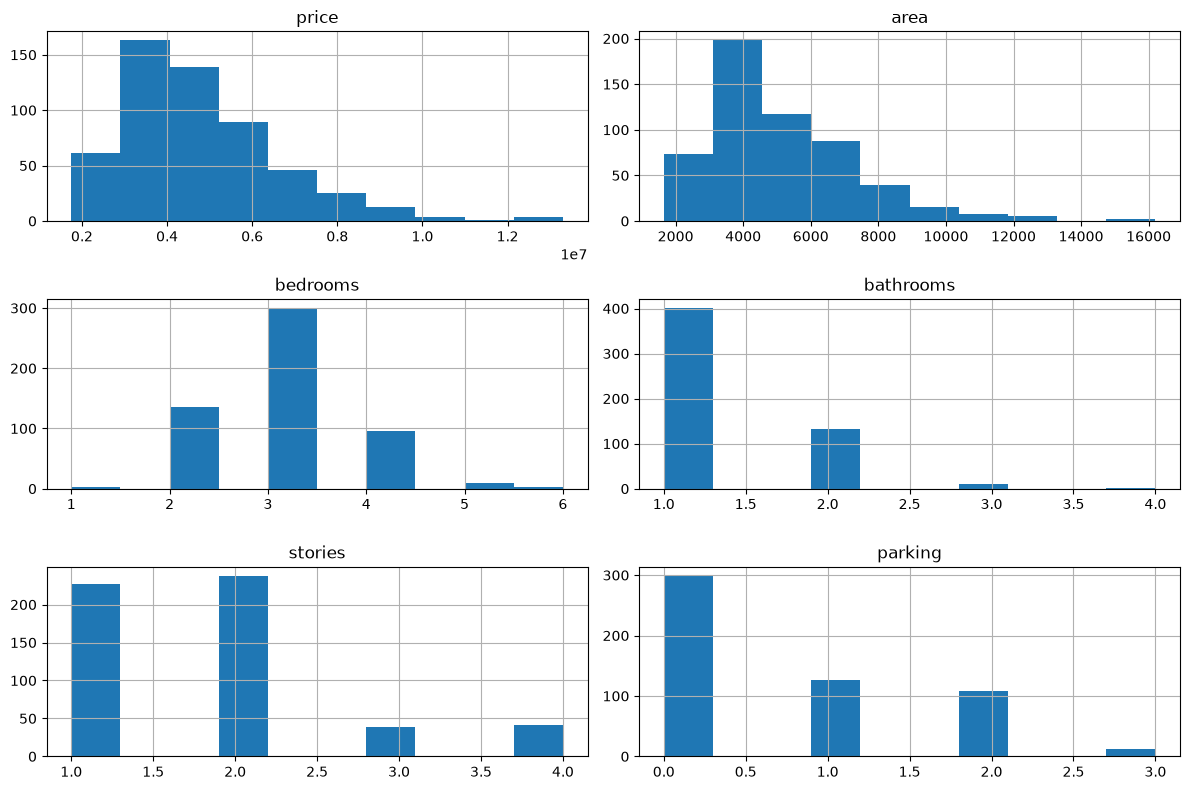

In [161]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

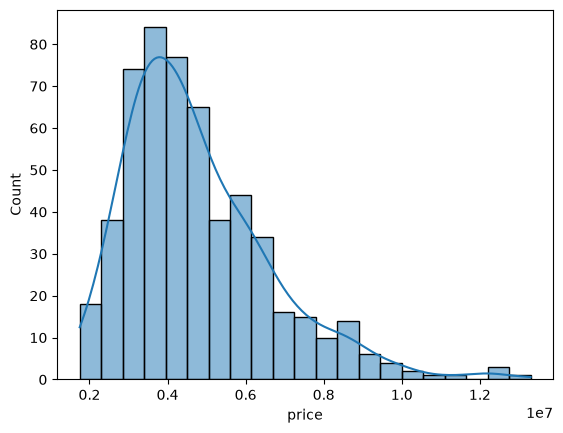

In [162]:
sns.histplot(df['price'], kde=True)
plt.show()

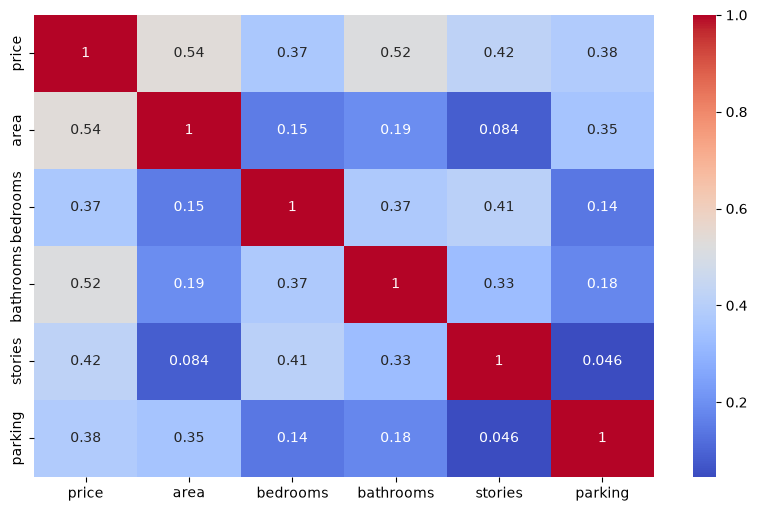

In [163]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

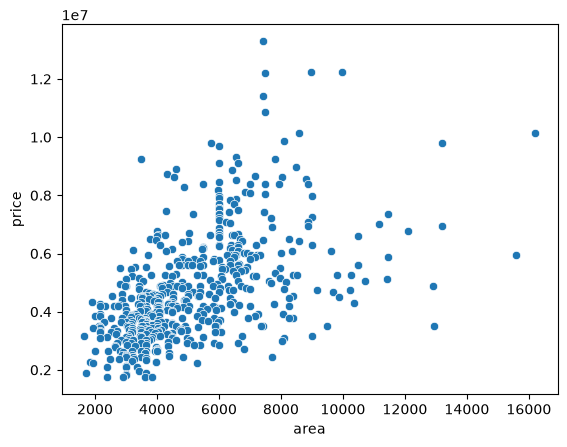

In [164]:
sns.scatterplot(data=df, x='area', y='price')
plt.show()

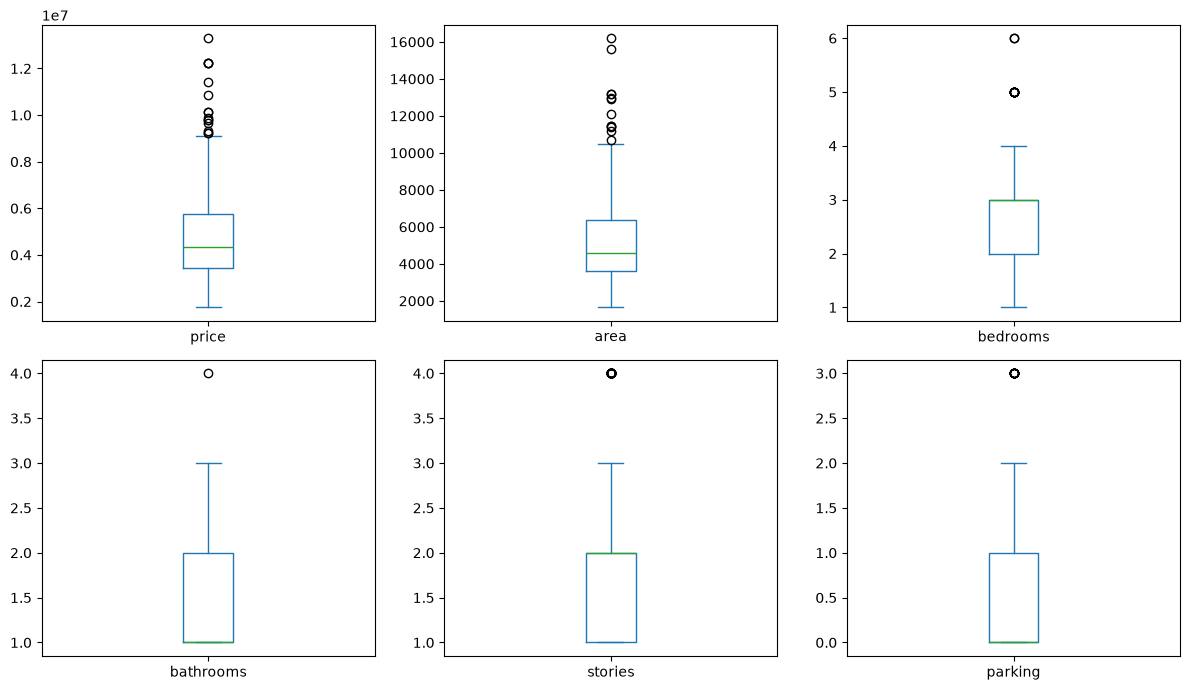

In [165]:
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

df[num_cols].plot(
    kind='box',
    subplots=True,
    layout=(2, 3),
    figsize=(12, 7)
)

plt.tight_layout()
plt.show()

In [166]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [167]:
from sklearn.preprocessing import LabelEncoder
# List of your columns to encode
columns_to_encode = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

# Initialize Label Encoder
le = LabelEncoder()

# Apply label encoding to each column in a loop
for col in columns_to_encode:
    df[col] = le.fit_transform(df[col])


df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True,
    dtype=int
)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [168]:
X = df.drop(['price'],axis=1)
y = df['price']

In [190]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.23, random_state=42)

In [191]:
y_train

173    5250000
393    3500000
69     6790000
331    3920000
333    3920000
        ...   
71     6755000
106    6160000
270    4340000
435    3290000
102    6195000
Name: price, Length: 419, dtype: int64

In [192]:
X_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,5900,4,2,2,0,0,1,0,0,1,0,0,1
77,6500,3,2,3,1,0,0,0,1,0,1,0,0
360,4040,2,1,1,1,0,0,0,0,0,0,1,0
90,5000,3,1,2,1,0,0,0,1,0,0,1,0
493,3960,3,1,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,7000,3,1,1,1,0,0,0,0,3,0,0,0
371,3570,3,1,2,1,0,1,0,0,0,0,1,0
373,3000,2,1,2,1,0,0,0,1,0,0,0,0
165,6450,3,2,1,1,1,1,1,0,0,0,0,1


In [193]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [194]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train_scaled,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 521136.13, 54420.38, 523513.05,..., 263377.64, -66593.38,-185768.65]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.743e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[32.24,26.28,25.04,...,15.43,13.07,12.28]"


In [195]:
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test,y_pred)
r2

0.673204258746978

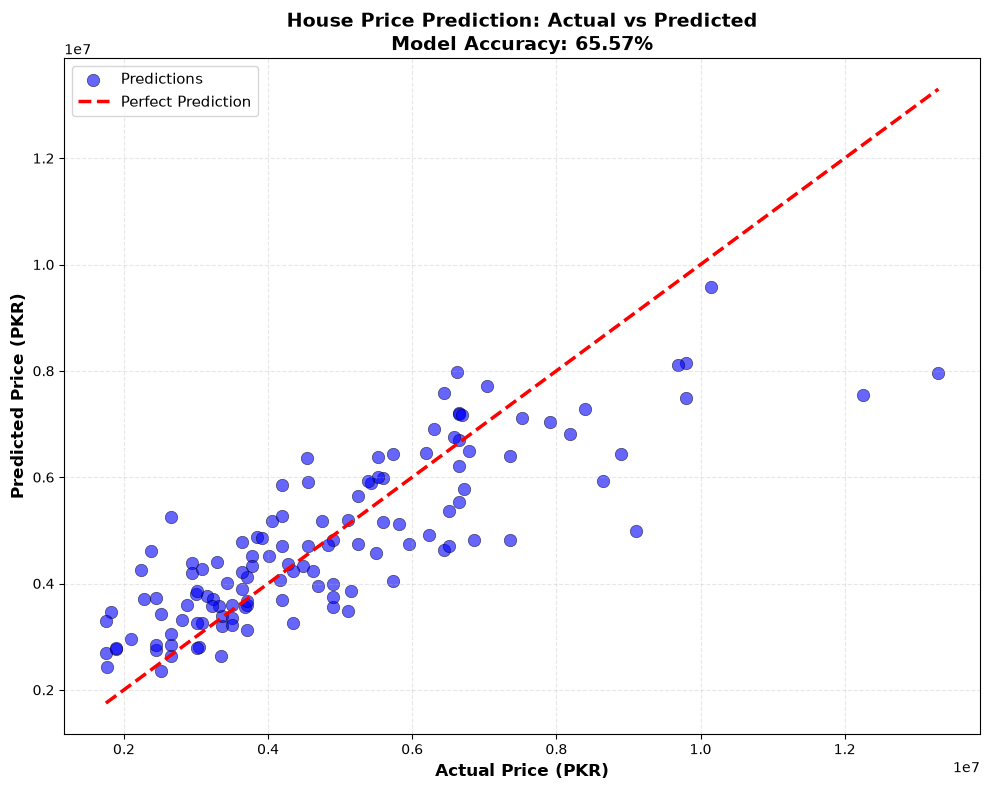


✅ Points close to red line = Accurate predictions
   Points far from line = Model made bigger errors


In [197]:
# SINGLE COMPARISON GRAPH: Actual vs Predicted
y_test_pred = model.predict(X_test_scaled)

plt.figure(figsize=(10, 8))

# Scatter plot
plt.scatter(y_test, y_test_pred, alpha=0.6, s=80, color='blue', label='Predictions', edgecolors='black', linewidth=0.5)

# Perfect prediction line (diagonal)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Perfect Prediction')

# Labels and title
plt.xlabel('Actual Price (PKR)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Price (PKR)', fontsize=12, fontweight='bold')
plt.title('House Price Prediction: Actual vs Predicted\nModel Accuracy: 65.57%', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n✅ Points close to red line = Accurate predictions")
print("   Points far from line = Model made bigger errors")


In [199]:
# Save Model and Scaler as Pickle Files
import pickle
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the trained model
with open('models/housing_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved: models/housing_model.pkl")
print("✅ Scaler saved: models/scaler.pkl")
print("\nModel Details:")
print(f"  - Type: Linear Regression")
print(f"  - Accuracy (R² Score): {r2:.4f} ({r2*100:.2f}%)")
print(f"  - Features used: {X.shape[1]}")
print(f"  - Training samples: {X_train.shape[0]}")
print(f"  - Test samples: {X_test.shape[0]}")


✅ Model saved: models/housing_model.pkl
✅ Scaler saved: models/scaler.pkl

Model Details:
  - Type: Linear Regression
  - Accuracy (R² Score): 0.6732 (67.32%)
  - Features used: 13
  - Training samples: 419
  - Test samples: 126
